In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
df = pd.DataFrame({
    '年龄': np.concatenate([np.random.randint(18, 35, 70), np.random.randint(30, 50, 80), np.random.randint(40, 65, 50)]),
    '年收入_万': np.concatenate([np.random.uniform(10, 30, 70), np.random.uniform(40, 80, 80), np.random.uniform(20, 45, 50)]),
    '消费分数': np.concatenate([np.random.uniform(60, 100, 70), np.random.uniform(60, 95, 80), np.random.uniform(10, 40, 50)]),
})

In [3]:
df

,年龄,年收入_万,消费分数
0,24,16.973320,73.462169
1,32,11.923531,86.228905
2,28,28.810465,75.415865
3,25,17.951440,87.264547
4,24,20.355027,73.624983
...,...,...,...
195,59,26.849028,31.791911
196,43,25.364728,26.423389
197,58,29.431477,23.527313
198,42,20.974078,37.314138


In [4]:
X_scaled = StandardScaler().fit_transform(df)

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [6]:
df['簇标签'] = kmeans.fit_predict(X_scaled)

E:\anaconda3\envs\MachineLearning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [7]:
df

,年龄,年收入_万,消费分数,簇标签
0,24,16.973320,73.462169,2
1,32,11.923531,86.228905,2
2,28,28.810465,75.415865,2
3,25,17.951440,87.264547,2
4,24,20.355027,73.624983,2
...,...,...,...,...
195,59,26.849028,31.791911,1
196,43,25.364728,26.423389,1
197,58,29.431477,23.527313,1
198,42,20.974078,37.314138,1


In [8]:
cluster_profile = df.groupby('簇标签').mean().round(1)

In [9]:
print("=== 各簇特征均值 ===")
print(cluster_profile)
print()

=== 各簇特征均值 ===
       年龄  年收入_万  消费分数
簇标签                   
0    38.4   57.7  77.2
1    51.1   32.7  25.1
2    26.2   21.4  81.4



In [10]:
label_names = {}
for idx, row in cluster_profile.iterrows():
    if row['消费分数'] > 60 and row['年收入_万'] < 30:
        label_names[idx] = '年轻月光族'
    elif row['年收入_万'] > 40:
        label_names[idx] = '高收入精英'
    else:
        label_names[idx] = '保守稳健型'

In [11]:
label_names

{0: '高收入精英', 1: '保守稳健型', 2: '年轻月光族'}

In [12]:
df['客户类型'] = df['簇标签'].map(label_names)

In [13]:
df

,年龄,年收入_万,消费分数,簇标签,客户类型
0,24,16.973320,73.462169,2,年轻月光族
1,32,11.923531,86.228905,2,年轻月光族
2,28,28.810465,75.415865,2,年轻月光族
3,25,17.951440,87.264547,2,年轻月光族
4,24,20.355027,73.624983,2,年轻月光族
...,...,...,...,...,...
195,59,26.849028,31.791911,1,保守稳健型
196,43,25.364728,26.423389,1,保守稳健型
197,58,29.431477,23.527313,1,保守稳健型
198,42,20.974078,37.314138,1,保守稳健型


In [14]:
print("=== 客户类型分布 ===")
print(df['客户类型'].value_counts())

=== 客户类型分布 ===
客户类型
高收入精英    80
年轻月光族    70
保守稳健型    50
Name: count, dtype: int64


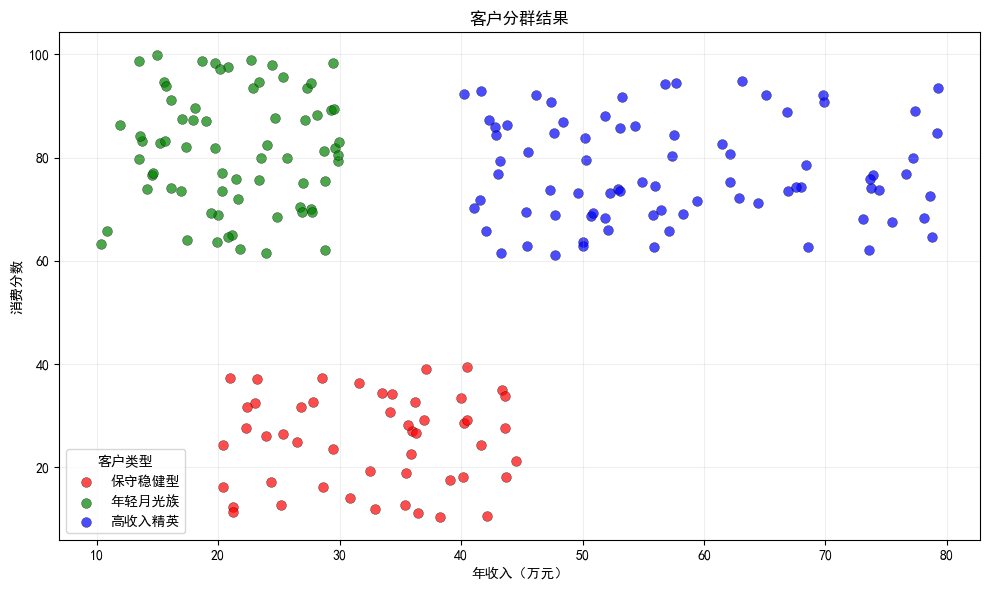

In [16]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
for i, (name, group) in enumerate(df.groupby('客户类型')):
    plt.scatter(group['年收入_万'], group['消费分数'],
                c=colors[i], label=name, s=50, alpha=0.7, edgecolors='k', linewidths=0.3)

plt.xlabel('年收入（万元）')
plt.ylabel('消费分数')
plt.title('客户分群结果')
plt.legend(title='客户类型')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()